# Project V2.2 — Anomaly Detection: CAE Training
**Environment:** Google Colab T4  
**Goal:** Train CAE on normal frames only, save best checkpoint to Google Drive.

## Cell 1 — Install Dependencies

In [1]:
!pip install pyyaml tqdm matplotlib --quiet
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')

PyTorch: 2.10.0+cu128
CUDA available: True
Device: cuda


## Cell 2 — Mount Google Drive & Set Paths

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Edit these two paths to match your Drive layout ──────────────────────────
DRIVE_PROJECT_DIR = '/content/drive/MyDrive/anomaly-detection'   # project root on Drive
DRIVE_CKPT_DIR   = '/content/drive/MyDrive/anomaly-detection/outputs/checkpoints'
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
print('Drive mounted. Checkpoint dir:', DRIVE_CKPT_DIR)

Mounted at /content/drive
Drive mounted. Checkpoint dir: /content/drive/MyDrive/anomaly-detection/outputs/checkpoints


## Cell 3 — Upload Project Files
Upload your project zip **or** clone from GitHub if repo is public.
The notebook expects `models/cae.py`, `scripts/preprocess.py`, and `configs/config.yaml`
to be accessible at `/content/anomaly-detection/`.

In [3]:
# Option A — clone from GitHub (replace with your repo URL after Phase 7)
# !git clone https://github.com/YOUR_USERNAME/project-v2.2-anomaly-detection.git /content/anomaly-detection

# # Option B — copy from Drive if you uploaded a zip there
!cp /content/drive/MyDrive/anomaly-detection/project.zip /content/
!unzip -q /content/project.zip -d /content/anomaly-detection

# Option C — project already on Drive, just symlink
import os
if not os.path.exists('/content/anomaly-detection'):
    os.symlink(DRIVE_PROJECT_DIR, '/content/anomaly-detection')

os.chdir('/content/anomaly-detection')
print('Working dir:', os.getcwd())
!ls

Working dir: /content/anomaly-detection
anomaly-detection  __MACOSX


## Cell 4 — Upload Dataset Frames
Upload the extracted training frames to Drive at:
`anomaly-detection/data/ucsd_ped1/training/frames/`

Fastest approach: zip the frames folder on M1, upload to Drive, unzip here.

In [7]:
# If frames are zipped on Drive:
# !unzip -q /content/drive/MyDrive/anomaly-detection/combined_normal_frames.zip \
#         -d data/combined_normal/
!unzip -q /content/drive/MyDrive/anomaly-detection/combined_normal_flow.zip \
        -d anomaly-detection/data/combined_normal/
# Verify
import glob
frames = glob.glob('anomaly-detection/data/combined_normal/frames/**/*.jpg', recursive=True)
print(f'Combined training frames found: {len(frames):,}')  # expect ~7162

Combined training frames found: 7,162


## Cell 5 — Config & Hyperparameters

In [8]:
import yaml

with open('anomaly-detection/configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Override training-specific settings for Colab
config['training']['num_workers'] = 2   # Colab can use workers

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device          :', DEVICE)
print('Epochs          :', config['training']['epochs'])
print('Batch size      :', config['training']['batch_size'])
print('Learning rate   :', config['training']['lr'])
print('Input channels  :', config['model']['input_channels'])
print('Resolution      :', config['dataset']['resolution'])

Device          : cuda
Epochs          : 60
Batch size      : 32
Learning rate   : 0.0001
Input channels  : 2
Resolution      : [256, 256]


## Cell 6 — DataLoaders

In [10]:
import sys
sys.path.insert(0, '/content/anomaly-detection/anomaly-detection/')

from torch.utils.data import DataLoader, random_split
from scripts.preprocess import NormalFrameDataset

flow_enabled = config['flow']['enabled']   # True now

full_ds = NormalFrameDataset(
    train_dir=config['dataset']['train_dir'],
    resolution=config['dataset']['resolution'],
    flow_enabled=flow_enabled,
)

val_size   = int(len(full_ds) * config['training']['val_split'])
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

train_loader = DataLoader(
    train_ds,
    batch_size=config['training']['batch_size'],
    shuffle=True,
    num_workers=config['training']['num_workers'],
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=config['training']['batch_size'],
    shuffle=False,
    num_workers=config['training']['num_workers'],
    pin_memory=True,
)

print(f'Train samples : {train_size:,}')
print(f'Val samples   : {val_size:,}')
print(f'Train batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')

[NormalFrameDataset] 7,162 frames | flow=ON
Train samples : 6,446
Val samples   : 716
Train batches : 202
Val batches   : 23


## Cell 7 — Model, Loss, Optimizer

In [11]:
from models.cae import build_model

model = build_model(config).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config['training']['lr'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)


Trainable parameters: 615,058


## Cell 8 — Training Loop

In [13]:
import os
from tqdm import tqdm

EPOCHS       = config['training']['epochs']
CKPT_PATH  = os.path.join(DRIVE_CKPT_DIR, 'best_model_flow.pth')
LOCAL_CKPT = 'outputs/checkpoints/best_model_flow.pth'
os.makedirs('outputs/checkpoints', exist_ok=True)

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for frames, _ in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} [train]', leave=False):
        frames = frames.to(DEVICE)
        optimizer.zero_grad()
        recon = model(frames)
        loss  = criterion(recon, frames)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────────────────────────
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for frames, _ in val_loader:
            frames = frames.to(DEVICE)
            recon  = model(frames)
            running_val += criterion(recon, frames).item()
    val_loss = running_val / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f'Epoch {epoch:03d}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}')

    # ---- LR Scheduler (PUT IT HERE) ----
    prev_lr = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss)

    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != prev_lr:
        print(f"LR reduced: {prev_lr} → {new_lr}")

    # ── Save best checkpoint ───────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        ckpt = {
            'epoch':      epoch,
            'state_dict': model.state_dict(),
            'val_loss':   val_loss,
            'config':     config,
        }
        torch.save(ckpt, LOCAL_CKPT)
        torch.save(ckpt, CKPT_PATH)   # save to Drive immediately
        print(f'  ✓ Best checkpoint saved (val_loss={val_loss:.6f})')

print(f'\nTraining complete. Best val loss: {best_val_loss:.6f}')
print(f'Checkpoint saved to Drive: {CKPT_PATH}')

Epoch 001/60 | Train Loss: 0.605947 | Val Loss: 0.580352
  ✓ Best checkpoint saved (val_loss=0.580352)


Epoch 002/60 | Train Loss: 0.560206 | Val Loss: 0.544833
  ✓ Best checkpoint saved (val_loss=0.544833)


Epoch 003/60 | Train Loss: 0.533351 | Val Loss: 0.524981
  ✓ Best checkpoint saved (val_loss=0.524981)


Epoch 004/60 | Train Loss: 0.516447 | Val Loss: 0.511198
  ✓ Best checkpoint saved (val_loss=0.511198)


Epoch 005/60 | Train Loss: 0.505045 | Val Loss: 0.501086
  ✓ Best checkpoint saved (val_loss=0.501086)


...

Epoch 056/60 | Train Loss: 0.465372 | Val Loss: 0.465901
  ✓ Best checkpoint saved (val_loss=0.465901)


Epoch 057/60 | Train Loss: 0.465369 | Val Loss: 0.465892
  ✓ Best checkpoint saved (val_loss=0.465892)


Epoch 058/60 | Train Loss: 0.465357 | Val Loss: 0.465888
  ✓ Best checkpoint saved (val_loss=0.465888)


Epoch 059/60 | Train Loss: 0.465355 | Val Loss: 0.465888
  ✓ Best checkpoint saved (val_loss=0.465888)


Epoch 060/60 | Train Loss: 0.465351 | Val Loss: 0.465878
  ✓ Best checkpoint saved (val_loss=0.465878)

Training complete. Best val loss: 0.465878
Checkpoint saved to Drive: /content/drive/MyDrive/anomaly-detection/outputs/checkpoints/best_model_flow.pth


## Cell 9 — Loss Curve

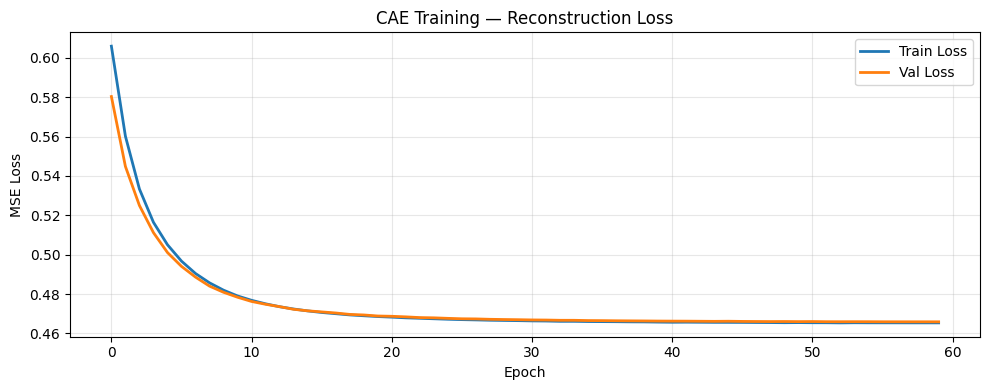

Loss curve saved to /content/drive/MyDrive/anomaly-detection/outputs/checkpoints/loss_curve.png


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('CAE Training — Reconstruction Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

curve_path = os.path.join(DRIVE_CKPT_DIR, 'loss_curve.png')
plt.savefig(curve_path, dpi=150)
plt.show()
print(f'Loss curve saved to {curve_path}')

## Cell 10 — Visual Sanity Check (Input vs Reconstruction)

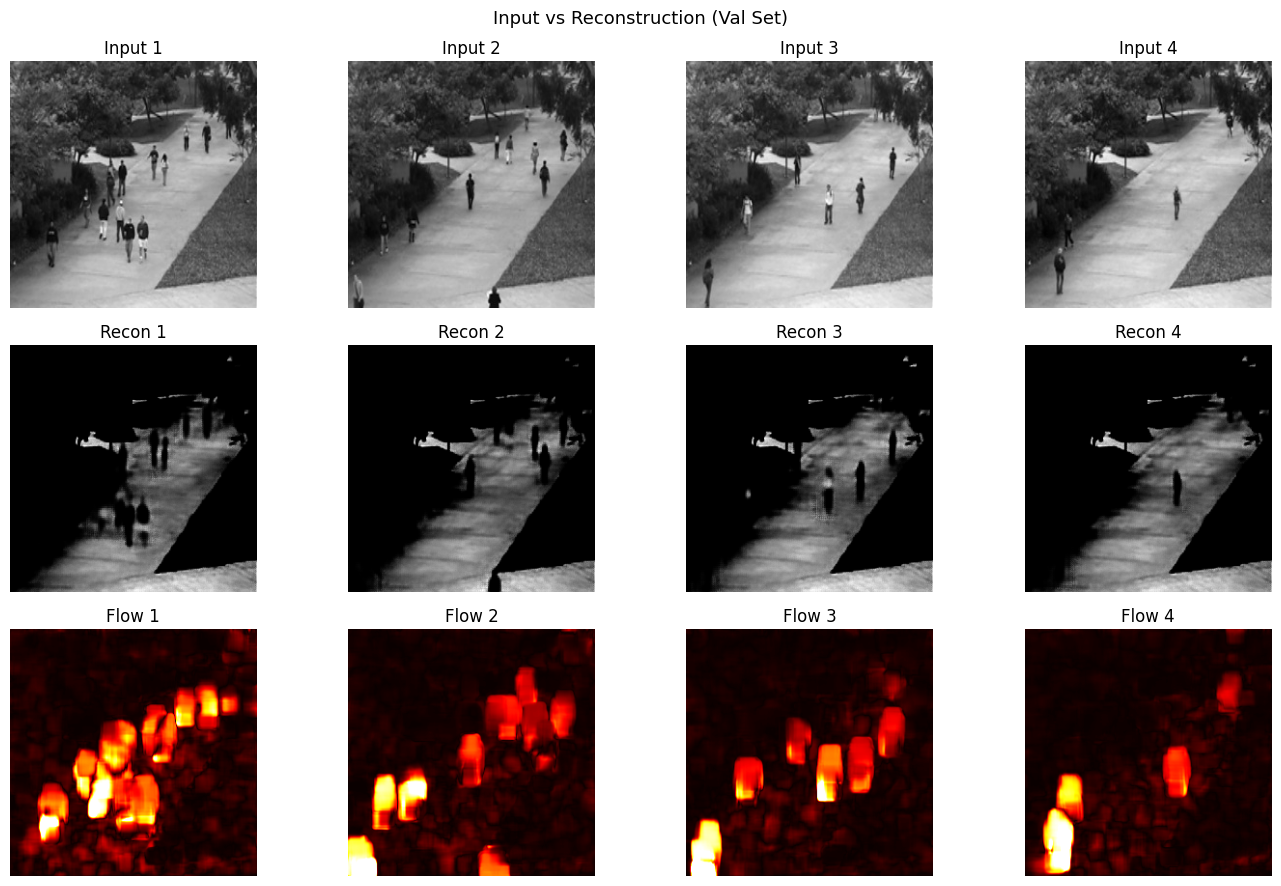

Sanity check saved to /content/drive/MyDrive/anomaly-detection/outputs/checkpoints/sanity_check.png


In [16]:
import numpy as np

model.eval()
sample_frames, _ = next(iter(val_loader))
sample_frames = sample_frames[:4].to(DEVICE)

with torch.no_grad():
    recons = model(sample_frames)

def denorm(t):
    """Reverse Normalize([0.5],[0.5]) → [0,1] → numpy HxW. Takes first channel only."""
    return ((t[0].cpu().numpy() * 0.5) + 0.5).clip(0, 1)  # channel 0 = grayscale

flow_enabled = config['flow']['enabled']
n_rows = 3 if flow_enabled else 2

fig, axes = plt.subplots(n_rows, 4, figsize=(14, 3 * n_rows))

for i in range(4):
    # Row 0: Input (grayscale channel)
    axes[0, i].imshow(denorm(sample_frames[i]), cmap='gray')
    axes[0, i].set_title(f'Input {i+1}')
    axes[0, i].axis('off')

    # Row 1: Reconstruction (grayscale channel)
    axes[1, i].imshow(denorm(recons[i]), cmap='gray')
    axes[1, i].set_title(f'Recon {i+1}')
    axes[1, i].axis('off')

    # Row 2 (flow only): Flow channel
    if flow_enabled:
        flow_map = ((sample_frames[i][1].cpu().numpy() * 0.5) + 0.5).clip(0, 1)
        axes[2, i].imshow(flow_map, cmap='hot')
        axes[2, i].set_title(f'Flow {i+1}')
        axes[2, i].axis('off')

plt.suptitle('Input vs Reconstruction (Val Set)', fontsize=13)
plt.tight_layout()

sanity_path = os.path.join(DRIVE_CKPT_DIR, 'sanity_check.png')
plt.savefig(sanity_path, dpi=150)
plt.show()
print(f'Sanity check saved to {sanity_path}')

## Cell 11 — Download Checkpoint to M1
After training, download `best_model.pth` from Google Drive to your M1:
```
outputs/checkpoints/best_model.pth
```
Place it in the same path inside your local project before starting Phase 4.

In [17]:
from google.colab import files
files.download(LOCAL_CKPT)
print('Checkpoint download triggered.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Checkpoint download triggered.
